In [1]:
import json
import os
import re
import fasttext
import lightning
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchmetrics
import unicodedata
from collections import Counter
from time import perf_counter
from bs4 import BeautifulSoup
from joblib import Parallel, delayed
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from email_content_dataset import PhishingDataset, collate_fn

torch.set_float32_matmul_precision("medium")

n_workers = min(4, os.cpu_count() - 1)

nltk.download('stopwords')
nltk.download('punkt_tab')
stop_en = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\navad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\navad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
email_df = pd.read_csv("dataset/emails/all_emails.csv")
email_df = email_df.dropna(subset=["subject", "body", "label"])
email_df["text"] = email_df["subject"] + " [SUBJECT] " + email_df["body"]
non_phishing_emails = email_df[email_df["label"] == 0]
phishing_emails = email_df[email_df["label"] == 1]
phishing_emails = phishing_emails.sample(
    n=len(non_phishing_emails),
    random_state=42
)
email_df = pd.concat(
    [non_phishing_emails, phishing_emails],
    ignore_index=True
)
email_df = email_df.sample(frac=1, random_state=42).reset_index(drop=True)
email_df

,sender,receiver,date,subject,body,label,urls,text
0,Julius <klklmvntmiq@gmx.net>,kpitck-aew45@python.org,"Wed, 06 Aug 2008 08:27:12 +0100","Re: [python-win32] win32gui.EnumWindows, docum...","On Tue, 2008-03-11 at 16:13 -0700, Tim Roberts...",0,1,"Re: [python-win32] win32gui.EnumWindows, docum..."
1,"""Carlos E. R."" <vyjwd.trpcau@telefonica.net>",OS-en <wkilxloc@opensuse.org>,"Wed, 06 Aug 2008 23:53:15 +0100",Re: [opensuse] ext3 check forced = frustration,-----BEGIN PGP SIGNED MESSAGE-----\nHash: SHA1...,0,0,Re: [opensuse] ext3 check forced = frustration...
2,Trent Nelson <ktctpxa@onresolve.com>,"""zvllln-eum@python.org"" <zvllln-eum@python.org>","Tue, 05 Aug 2008 19:43:39 -0800",Re: [Python-Dev] Windows buildbots randomly di...,Had a chat with some Twisted/buildbot folk and...,0,1,Re: [Python-Dev] Windows buildbots randomly di...
3,Wade Rush <slurpingi87@fuse.net>,user2.15@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 19:34:35 +0100",Ohne Rezept - kein Potenmiitl!,The commanders of the troops which were sum mo...,1,0,Ohne Rezept - kein Potenmiitl! [SUBJECT] The c...
4,Melissa Looney <akstcactivamnsdgs@activa.com>,user2.15@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 23:54:37 -0300",Extraordinary Pill Deals,\nEngaging Substance Satisfactions\n\nhttp://i...,1,1,Extraordinary Pill Deals [SUBJECT] \nEngaging ...
...,...,...,...,...,...,...,...,...
41527,"""\\""Martin v. Löwis\\"""" <qpnysl@v.loewis.de>",David Wolever <aywfqwr@cs.toronto.edu>,"Wed, 06 Aug 2008 11:30:54 -0500",Re: [Python-Dev] Pretty-printing 2to3 Nodes,"> OR just names:\n> Node(import_name, [Leaf(1,...",0,1,Re: [Python-Dev] Pretty-printing 2to3 Nodes [S...
41528,Adi Botea <ayc.oscwi@nicta.com.au>,"bdard-buthszfgfn@googlegroups.com, faq@engr.or...","Fri, 08 Aug 2008 02:37:40 +1100",[UAI] ICKEPS 2007: CALL for PARTICIPATION,[Apologies for cross postings]\n\n\n\t\t\tCALL...,0,1,[UAI] ICKEPS 2007: CALL for PARTICIPATION [SUB...
41529,Daily Top 10 <niamh-tlebujre@molen.net>,user3@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 08:03:29 -0400",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,CNN.com Daily Top 10 [SUBJECT] >+=+=+=+=+=+=+=...
41530,"""SourceForge.net"" <uiaregi@sourceforge.net>",uiaregi@sourceforge.net,"Tue, 05 Aug 2008 18:32:28 -0700",[ spambayes-Patches-858925 ] Add notification ...,"Patches item #858925, was opened at 2003-12-12...",0,1,[ spambayes-Patches-858925 ] Add notification ...


In [3]:
def strip_html(text):
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)
    text = re.sub(r"&[a-z]+;", " ", text)
    return text


def mask_entities(text):
    text = re.sub(r"http[s]?://\S+", " ___URL___ ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ___EMAIL___ ", text)
    text = re.sub(r"\d+(?:[\.,]\d+)*", " ___NUM___ ", text)
    return text


def normalize_text(text):
    text = text.lower()
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_punctuation(text):
    text = re.sub(r"[^a-z0-9_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_and_remove_stopwords(text):
    return [t for t in word_tokenize(text) if t not in stop_en]


def clean_text_pipeline(raw):
    text = strip_html(raw)
    text = mask_entities(text)
    text = normalize_text(text)
    text = remove_punctuation(text)
    return tokenize_and_remove_stopwords(text)

In [4]:
email_df["tokens"] = Parallel(n_jobs=4, backend="loky", verbose=2)(
    delayed(clean_text_pipeline)(txt) for txt in email_df["text"]
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    1.7s
[Parallel(n_jobs=4)]: Done 19980 tasks      | elapsed:    6.6s
[Parallel(n_jobs=4)]: Done 41532 out of 41532 | elapsed:   10.7s finished


In [5]:
string_to_integer = {"<pad>": 0, "<unk>": 1}

if not os.path.exists("email_data/vocab.json"):
    VOCAB_SIZE = 25_000
    MIN_FREQ = 5
    RESERVED = ["<pad>", "<unk>", "___url___", "___email___", "___num___"]

    all_tokens = [tok for tokens in email_df['tokens'] for tok in tokens]
    counter = Counter(all_tokens)
    most_common = counter.most_common(25_000)

    for idx, (tok, _) in enumerate(most_common, start=2):
        string_to_integer[tok] = idx
    integer_to_string = {idx: tok for tok, idx in string_to_integer.items()}

    import json

    with open('email_data/vocab.json', 'w', encoding='utf-8') as f:
        json.dump(string_to_integer, f, ensure_ascii=False, indent=2)

else:
    with open('email_data/vocab.json', "r", encoding="utf-8") as f:
        string_to_integer = json.load(f)

In [6]:
if os.path.exists("email_data/embedding_matrix.npy"):
    embedding_matrix = np.load("email_data/embedding_matrix.npy", "r", )
else:
    ft = fasttext.load_model("dataset/emails/cc.en.300.bin")
    EMB_DIM = ft.get_dimension()

    vocab_size = len(string_to_integer)
    pad_idx = string_to_integer["<pad>"]
    unk_idx = string_to_integer["<unk>"]

    embedding_matrix = np.zeros((vocab_size, EMB_DIM), dtype=np.float32)

    for token, idx in string_to_integer.items():
        if idx in (pad_idx, unk_idx):
            continue
        try:
            embedding_matrix[idx] = ft.get_word_vector(token)
        except Exception:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMB_DIM,))

    np.save("email_data/embedding_matrix.npy", embedding_matrix)

In [7]:
unk = string_to_integer["<unk>"]


def encode(tokens):
    return [string_to_integer.get(t, unk) for t in tokens]


email_df["encoded"] = email_df["tokens"].apply(encode)

In [8]:
X = email_df['encoded'].tolist()
y = email_df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

train_ds = PhishingDataset(X_train, y_train)
val_ds = PhishingDataset(X_val, y_val)
test_ds = PhishingDataset(X_test, y_test)

batch_size = 32
loader_kwargs = dict(
    batch_size=batch_size,
    collate_fn=collate_fn,
    num_workers=n_workers,
    pin_memory=True,
    persistent_workers=(n_workers > 0)
)

train_loader = DataLoader(train_ds, shuffle=True, drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_kwargs)

In [9]:
class LitPhishingLSTM(lightning.LightningModule):
    def __init__(self, embedding_matrix_arg, hidden_dim=64,
                 num_layers=1, dropout=0.35, pad_idx_arg=0, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=["embedding_matrix_arg"])

        self.lr = lr

        weights = torch.tensor(embedding_matrix_arg)
        self.embedding = nn.Embedding.from_pretrained(
            weights, freeze=False, padding_idx=pad_idx_arg
        )
        self.emb_drop = nn.Dropout1d(0.2)

        self.lstm = nn.LSTM(
            input_size=weights.shape[1],
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.criterion = nn.BCEWithLogitsLoss()

        self.train_acc = torchmetrics.Accuracy(threshold=0.5, task="binary")
        self.train_precision = torchmetrics.Precision(threshold=0.5, task="binary")
        self.train_rec = torchmetrics.Recall(threshold=0.5, task="binary")
        self.train_f1 = torchmetrics.F1Score(threshold=0.5, task="binary")

        self.val_acc = torchmetrics.Accuracy(threshold=0.5, task="binary")
        self.val_precision = torchmetrics.Precision(threshold=0.5, task="binary")
        self.val_rec = torchmetrics.Recall(threshold=0.5, task="binary")
        self.val_f1 = torchmetrics.F1Score(threshold=0.5, task="binary")

        self.test_acc = torchmetrics.Accuracy(threshold=0.5, task="binary")
        self.test_precision = torchmetrics.Precision(threshold=0.5, task="binary")
        self.test_recall = torchmetrics.Recall(threshold=0.5, task="binary")
        self.test_f1 = torchmetrics.F1Score(threshold=0.5, task="binary")

    def forward(self, x, lengths):
        emb = self.emb_drop(self.embedding(x).transpose(1, 2)).transpose(1, 2)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        pooled, _ = torch.max(out, 1)
        return self.fc(pooled).squeeze(1)

    def _common_step(self, batch):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = self.criterion(logits, y)
        probs = torch.sigmoid(logits)
        return loss, probs, y

    def training_step(self, batch, batch_idx):
        loss, probs, y = self._common_step(batch)
        self.train_acc.update(probs, y)
        self.train_precision.update(probs, y)
        self.train_rec.update(probs, y)
        self.train_f1.update(probs, y)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        self.log_dict({
            "train_acc": self.train_acc.compute(),
            "train_precision": self.train_precision.compute(),
            "train_rec": self.train_rec.compute(),
            "train_f1": self.train_f1.compute()
        }, prog_bar=True)
        self.train_acc.reset()
        self.train_precision.reset()
        self.train_rec.reset()
        self.train_f1.reset()

    def validation_step(self, batch, batch_idx):
        loss, probs, y = self._common_step(batch)
        self.val_acc.update(probs, y)
        self.val_precision.update(probs, y)
        self.val_rec.update(probs, y)
        self.val_f1.update(probs, y)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)

    def on_validation_epoch_end(self):
        self.log_dict({
            "val_acc": self.val_acc.compute(),
            "val_precision": self.val_precision.compute(),
            "val_rec": self.val_rec.compute(),
            "val_f1": self.val_f1.compute(),
        }, prog_bar=True)
        self.val_acc.reset()
        self.val_precision.reset()
        self.val_rec.reset()
        self.val_f1.reset()

    def test_step(self, batch, batch_idx):
        loss, probs, y = self._common_step(batch)
        self.test_acc.update(probs, y)
        self.test_precision.update(probs, y)
        self.test_recall.update(probs, y)
        self.test_f1.update(probs, y)
        self.log("test_loss", loss, prog_bar=False)

    def on_test_epoch_end(self):
        self.log_dict({
            "test_acc": self.test_acc.compute(),
            "test_precision": self.test_precision.compute(),
            "test_rec": self.test_recall.compute(),
            "test_f1": self.test_f1.compute(),
        }, prog_bar=True)
        self.test_acc.reset()
        self.test_precision.reset()
        self.test_recall.reset()
        self.test_f1.reset()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-2)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "val_loss"}}


In [10]:
model = LitPhishingLSTM(
    embedding_matrix_arg=embedding_matrix,
    hidden_dim=32,
    num_layers=1,
    dropout=0.35,
    pad_idx_arg=string_to_integer["<pad>"],
    lr=1e-4
)

es = EarlyStopping(monitor="val_loss", patience=3, mode="min")
ckpt = ModelCheckpoint(
    monitor="val_f1",
    mode="max",
    filename="best-phishing-lstm",
    save_top_k=3
)

csv_logger = CSVLogger("lightning_logs", name="phishing-lstm")

trainer = Trainer(
    max_epochs=15,
    accelerator="gpu",
    devices=1,
    deterministic=False,
    callbacks=[es, ckpt],
    log_every_n_steps=50,
    gradient_clip_val=1.0,
    logger=csv_logger,
)

trainer.fit(model, train_loader, val_loader)
trainer.test(model, dataloaders=test_loader)

F:\Repositories\ParanoidViking\Detection_Models\.venv\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.35 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name            | Type              | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0  | embedding       | Embedding         | 7.5 M  | train | 0    
1  | emb_drop        | Dropout1d         | 0      | train | 0    
2  | lstm            | LSTM              | 85.5 K | train | 0 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

F:\Repositories\ParanoidViking\Detection_Models\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0: 100%|██████████| 908/908 [00:34<00:00, 26.21it/s, v_num=0]        
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 908/908 [00:34<00:00, 26.19it/s, v_num=0, val_loss=0.0877, val_acc=0.986, val_precision=0.986, val_rec=0.986, val_f1=0.986, train_loss=0.364, train_acc=0.887, train_precision=0.865, train_rec=0.916, train_f1=0.890]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 908/908 [00:33<00:00, 26.85it/s, v_num=0, val_loss=0.0365, val_acc=0.992, val_precision=0.994, val_rec=0.991, val_f1=0.992, train_loss=0.0527, train_acc=0.991, train_precision=0.992, train_rec=0.989, train_f1=0.991]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 908/908 [00:33<00:00, 27.21it/s, v_num=0, val_loss=0.0253, val_acc=0.994, val_precision=0.994, val_rec=0.994, val_f1=0.994, train_loss=0.02

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 908/908 [00:39<00:00, 23.08it/s, v_num=0, val_loss=0.0163, val_acc=0.996, val_precision=0.996, val_rec=0.996, val_f1=0.996, train_loss=0.000632, train_acc=1.000, train_precision=1.000, train_rec=1.000, train_f1=1.000]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 195/195 [00:03<00:00, 59.78it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9958266615867615
         test_f1            0.9958373308181763
        test_loss           0.01615265943109989
     test_precision         0.9932928681373596
        test_rec            0.9983948469161987
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.01615265943109989,
  'test_acc': 0.9958266615867615,
  'test_precision': 0.9932928681373596,
  'test_rec': 0.9983948469161987,
  'test_f1': 0.9958373308181763}]

In [11]:
def plot_confusion_matrix(y_true_arg, y_pred_arg, labels=None, normalize=True, cmap="Blues"):
    c_matrix = confusion_matrix(
        y_true_arg, y_pred_arg, normalize="true" if normalize else None
    )
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(c_matrix, interpolation="nearest", cmap=cmap, vmin=0, vmax=1 if normalize else None)
    ax.set(title="Confusion Matrix",
           xlabel="Predicted label", ylabel="True label")

    if labels is None:
        labels = ["0", "1"]
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)

    for i in range(c_matrix.shape[0]):
        for j in range(c_matrix.shape[1]):
            val = f"{c_matrix[i, j]:.2f}" if normalize else f"{c_matrix[i, j]:d}"
            color = "white" if c_matrix[i, j] > (0.5 if normalize else c_matrix.max() / 2) else "black"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

    return c_matrix


def plot_roc_auc(y_true_arg, y_scores_arg, threshold=0.5):
    fpr, tpr, thresh = roc_curve(y_true_arg, y_scores_arg)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(4, 4))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    idx = np.argmin(np.abs(thresh - threshold))
    plt.scatter(fpr[idx], tpr[idx], marker="o", color="red",
                label=f"thr={threshold:.2f}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return roc_auc

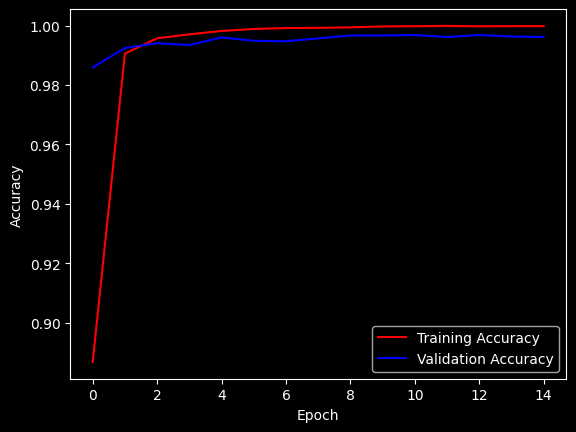

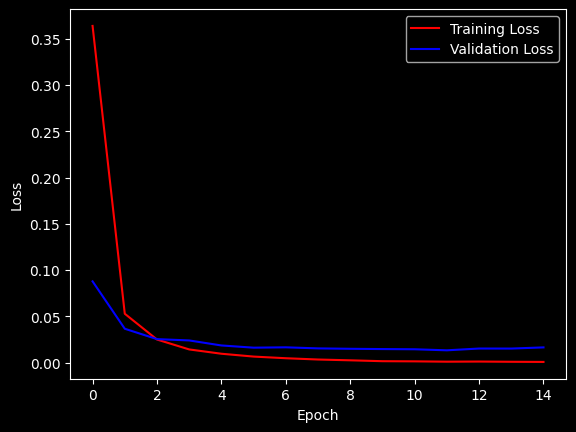

In [32]:
def plot_train_and_validation_metrics(path: str):
    data = pd.read_csv(path)
    train_data = data[1::2]
    val_data = data[0::2]

    plt.plot(train_data["train_acc"].tolist(), linestyle='-', label="Training Accuracy", color="red")
    plt.plot(val_data["val_acc"].tolist(), linestyle='-', label="Validation Accuracy", color="blue")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.plot(train_data["train_loss"].tolist(), linestyle='-', label="Training Loss", color="red")
    plt.plot(val_data["val_loss"].tolist(), linestyle='-', label="Validation Loss", color="blue")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_train_and_validation_metrics("lightning_logs/phishing-lstm/version_0/metrics.csv")

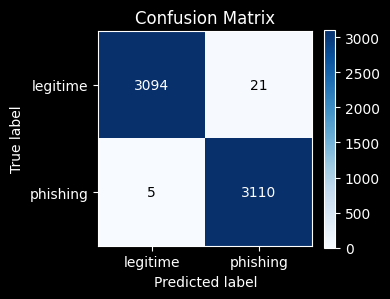

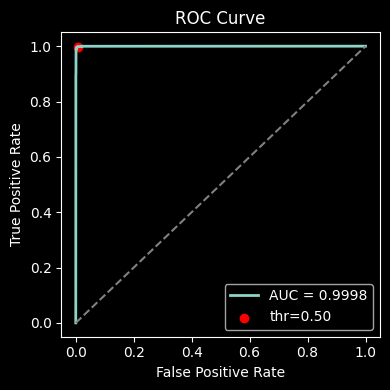

0.9997536386098436

In [12]:
y_true, y_pred, y_scores = [], [], []
model.eval()
with torch.no_grad():
    for xb, lengths, yb in test_loader:
        xb = xb.to(model.device)
        lengths = lengths.to(model.device)
        logits = model(xb, lengths).cpu()
        probs = torch.sigmoid(logits)

        y_true.extend(yb.cpu().tolist())
        y_pred.extend((probs >= 0.5).long().tolist())
        y_scores.extend(probs.tolist())

cm = plot_confusion_matrix(y_true, y_pred, normalize=False, labels=['legitimate', 'phishing'])
plot_roc_auc(y_true, y_scores)

In [13]:
def bootstrap_ci(y_true, y_scores, thr=0.5, n_boot=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    metrics = {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []}

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, ys = y_true[idx], y_scores[idx]
        yp = (ys >= thr).astype(int)

        metrics["acc"].append(accuracy_score(yt, yp))
        metrics["prec"].append(precision_score(yt, yp, zero_division=0))
        metrics["rec"].append(recall_score(yt, yp))
        metrics["f1"].append(f1_score(yt, yp))
        metrics["auc"].append(roc_auc_score(yt, ys))

    ci = {
        m: (np.percentile(vals, 100 * alpha / 2),
            np.percentile(vals, 100 * (1 - alpha / 2)))
        for m, vals in metrics.items()
    }
    return ci


ci95 = bootstrap_ci(y_true, y_scores, thr=0.5)

for m, (lo, hi) in ci95.items():
    print(f"{m.upper():5s} 95% CI: {lo:.4f} – {hi:.4f}")

ACC   95% CI: 0.9941 – 0.9973
PREC  95% CI: 0.9900 – 0.9958
REC   95% CI: 0.9968 – 0.9997
F1    95% CI: 0.9940 – 0.9973
AUC   95% CI: 0.9995 – 1.0000


In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

tok_ids = torch.tensor(X_test[0]).to(device)
length = torch.tensor([tok_ids.numel()]).to(device)

tok_ids = tok_ids.unsqueeze(0)

N, times = 100, []
with torch.inference_mode():
    for _ in range(N):
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = perf_counter()

        _ = model(tok_ids, length)

        if device == "cuda":
            torch.cuda.synchronize()
        times.append(perf_counter() - t0)

mean = sum(times) / N * 1000
std = torch.std(torch.tensor(times)) * 1000
print(f"Medie: {mean:.2f} ms  |  Dev. std: {std:.2f} ms")


Medie: 4.31 ms  |  Dev. std: 0.31 ms


In [26]:
nigerian_df = pd.read_csv("dataset/emails/Nigerian_Fraud.csv")

nigerian_df = nigerian_df.dropna(subset=["subject", "body", "label"])
nigerian_df["text"] = nigerian_df["subject"] + " [SUBJECT] " + nigerian_df["body"]

nigerian_df["tokens"] = Parallel(n_jobs=4, backend="loky", verbose=2)(
    delayed(clean_text_pipeline)(txt) for txt in nigerian_df["text"]
)

nigerian_df["encoded"] = nigerian_df["tokens"].apply(encode)

X = nigerian_df['encoded'].tolist()
y = nigerian_df['label'].tolist()

nigerian_dataset = PhishingDataset(X, y)
nigerian_dataloader = DataLoader(nigerian_dataset, shuffle=True, drop_last=True, **loader_kwargs)
trainer.test(model, dataloaders=nigerian_dataloader)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    2.4s
[Parallel(n_jobs=4)]: Done 3293 out of 3293 | elapsed:    3.8s finished
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
F:\Repositories\ParanoidViking\Detection_Models\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
F:\Repositories\ParanoidViking\Detection_Models\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Testing DataLoader 0: 100%|██████████| 102/102 [00:02<00:00, 46.74it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7931985259056091
         test_f1            0.8846745491027832
        test_loss           0.9152301549911499
     test_precision                 1.0
        test_rec            0.7931985259056091
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.9152301549911499,
  'test_acc': 0.7931985259056091,
  'test_precision': 1.0,
  'test_rec': 0.7931985259056091,
  'test_f1': 0.8846745491027832}]

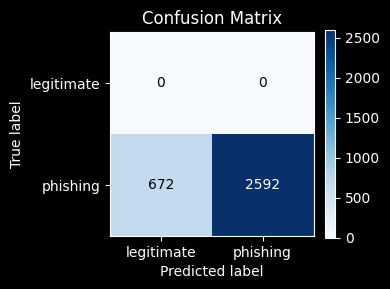

In [29]:
y_true, y_pred, y_scores = [], [], []
model.eval()
with torch.no_grad():
    for xb, lengths, yb in nigerian_dataloader:
        xb = xb.to(model.device)
        lengths = lengths.to(model.device)
        logits = model(xb, lengths).cpu()
        probs = torch.sigmoid(logits)

        y_true.extend(yb.cpu().tolist())
        y_pred.extend((probs >= 0.5).long().tolist())
        y_scores.extend(probs.tolist())

cm = plot_confusion_matrix(y_true, y_pred, normalize=False, labels=['legitimate', 'phishing'])